# Merkel / Meissner responses for eight materials

8素材について、触覚センサ信号からMerkel応答とMeissner応答を計算し、2行4列のパネルとして描画します。`SAMPLE_ID`を変更すると別試行を表示できます。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Settings
# =========================
SAMPLE_ID = 1
CHANNEL = 0
START_INDEX = 3000
END_INDEX = 8000
DT_S = 0.1e-3
MERKEL_SCALE = 0.4 * 0.02
MEISSNER_SCALE = 0.6 * 7.3 * 0.02

MATERIALS = [
    ("Al_board",     "aluminum bd."),
    ("rubber_board", "rubber bd."),
    ("wood_board",   "wood bd."),
    ("buta_omote",   "outer pigskin"),
    ("buta_ura",     "back pigskin"),
    ("cork",         "cork"),
    ("denim",        "denim"),
    ("washi",        "Japanese paper"),
]

# Notebookをanalysisから開いてもcodeから開いてもデータを発見できるようにする
cwd = Path.cwd().resolve()
data_candidates = [
    cwd / "tactile_data",
    cwd.parent / "tactile_data",
    cwd.parent.parent / "tactile_data",
    Path(r"C:\Users\haru4\研究\研究コード\tactile_data"),
]
DATA_ROOT = next((p for p in data_candidates if p.is_dir()), None)
if DATA_ROOT is None:
    raise FileNotFoundError("tactile_dataフォルダーが見つかりません。data_candidatesを確認してください。")

OUTPUT_DIR = (cwd / "analysis") if (cwd / "analysis").is_dir() else cwd
OUTPUT_PNG = OUTPUT_DIR / "merkel_meissner_8materials.png"
OUTPUT_PDF = OUTPUT_DIR / "merkel_meissner_8materials.pdf"
print(f"DATA_ROOT: {DATA_ROOT}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

DATA_ROOT: C:\Users\haru4\研究\研究コード\tactile_data
OUTPUT_DIR: C:\Users\haru4\研究\研究コード\code\analysis


In [2]:
def calc_meissner(data, dt=DT_S):
    """Meissner型の速順応応答を計算する。"""
    data = np.asarray(data, dtype=float)
    response = np.zeros_like(data)
    for i in range(1, data.size):
        d_force_dt = abs(data[i] - data[i - 1]) / dt
        response[i] = response[i - 1] + d_force_dt - response[i - 1] * dt / (8e-3)
    return response


def calc_merkel(data, dt=DT_S):
    """Merkel型の遅順応応答を計算する。"""
    data = np.asarray(data, dtype=float)
    state = np.zeros((3, data.size), dtype=float)
    for i in range(1, data.size):
        d_force_dt = abs(data[i] - data[i - 1]) / dt
        state[0, i] = state[0, i - 1] + 0.74 * d_force_dt - state[0, i - 1] * dt / (8e-3)
        state[1, i] = (
            state[1, i - 1] + 0.24 * d_force_dt
            - (state[1, i - 1] - 0.24 * 0.13) * dt / (200e-3)
        )
        state[2, i] = state[2, i - 1] + 0.07 * d_force_dt - state[2, i - 1] * dt / (1744.6e-3)
    return state.sum(axis=0)


def load_material_signal(material_key, sample_id=SAMPLE_ID, channel=CHANNEL):
    files = sorted((DATA_ROOT / material_key).glob(f"data_{sample_id}_*"))
    if not files:
        raise FileNotFoundError(f"{material_key}: data_{sample_id}_* が見つかりません。")
    frame = pd.read_csv(files[0], sep=r"\s+", header=None)
    if not 0 <= channel < frame.shape[1]:
        raise IndexError(f"CHANNEL={channel} は範囲外です（列数={frame.shape[1]}）。")
    signal = frame.iloc[START_INDEX:END_INDEX, channel].to_numpy(dtype=float)
    if signal.size != END_INDEX - START_INDEX:
        raise ValueError(f"{files[0].name}: 指定区間のデータ数が不足しています。")
    return signal, files[0]


responses = {}
for key, label in MATERIALS:
    raw_signal, source_file = load_material_signal(key)
    responses[key] = {
        "label": label,
        "merkel": MERKEL_SCALE * calc_merkel(raw_signal),
        "meissner": MEISSNER_SCALE * calc_meissner(raw_signal),
        "source": source_file,
    }

time_s = np.arange(END_INDEX - START_INDEX) * DT_S
print(f"Loaded {len(responses)} materials; duration={time_s[-1] + DT_S:.3f} s")

Loaded 8 materials; duration=0.500 s


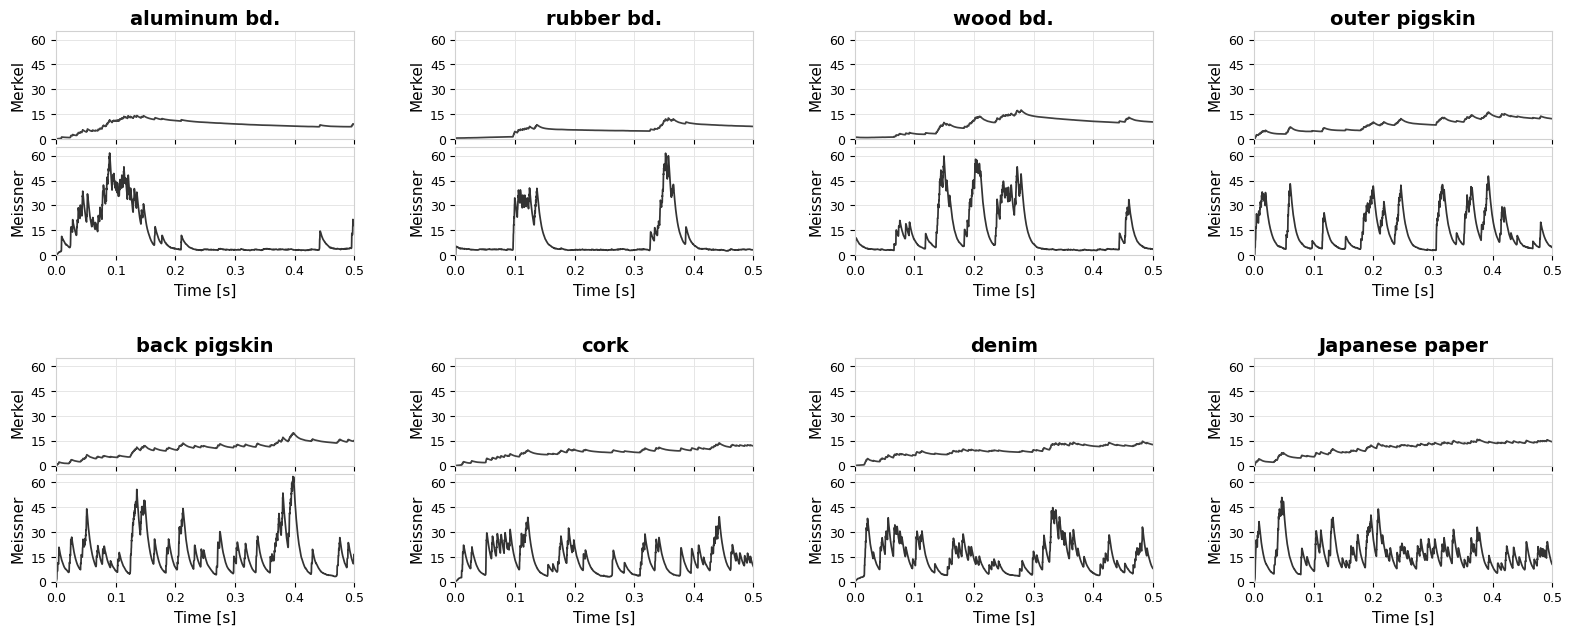

Saved: C:\Users\haru4\研究\研究コード\code\analysis\merkel_meissner_8materials.png
Saved: C:\Users\haru4\研究\研究コード\code\analysis\merkel_meissner_8materials.pdf


In [3]:
# =========================
# Plot
# =========================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

fig = plt.figure(figsize=(16, 6.4), constrained_layout=False)
outer = fig.add_gridspec(2, 4, hspace=0.46, wspace=0.34)

for material_index, (key, label) in enumerate(MATERIALS):
    row, col = divmod(material_index, 4)
    inner = outer[row, col].subgridspec(2, 1, hspace=0.08)
    ax_merkel = fig.add_subplot(inner[0])
    ax_meissner = fig.add_subplot(inner[1], sharex=ax_merkel)

    ax_merkel.plot(time_s, responses[key]["merkel"], color="0.25", linewidth=1.25)
    ax_meissner.plot(time_s, responses[key]["meissner"], color="0.20", linewidth=1.25)

    ax_merkel.set_title(label, fontweight="semibold", pad=5)
    ax_merkel.set_ylabel("Merkel")
    ax_meissner.set_ylabel("Meissner")
    ax_meissner.set_xlabel("Time [s]")

    for ax in (ax_merkel, ax_meissner):
        ax.set_xlim(0.0, 0.5)
        ax.set_ylim(0, 65)
        ax.set_yticks([0, 15, 30, 45, 60])
        ax.grid(True, color="0.90", linewidth=0.7)
        ax.set_axisbelow(True)
        for spine in ax.spines.values():
            spine.set_color("0.82")

    ax_merkel.tick_params(axis="x", labelbottom=False)

fig.subplots_adjust(left=0.055, right=0.99, bottom=0.10, top=0.96)
fig.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_PDF, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_PNG}")
print(f"Saved: {OUTPUT_PDF}")